# Inference and Clustering

In [5]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re
import sys

import skimage
import tifffile
import time
import torch
import torch.hub
import torch.nn


from MicNet_model import *
from utils_data import Dataset
from utils_data import normalize, augmentor
from utils_eval import NCESoftmaxLoss, NCECriterion


## 1) Load data

(11607, 11620, 3)


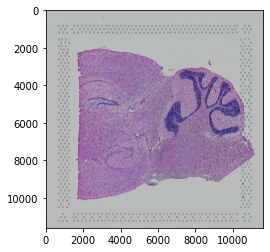

In [7]:
count_stat = pd.read_csv("./output/Dataset_MPB/1_count_stat_mouse_brain.csv", index_col=0)
count = pd.read_csv("./output/Dataset_MPB/1_pd_count_norm_mouse_brain.csv", index_col=0)

image_file = "./Sample_data/Dataset_MPB/V1_Mouse_Brain_Sagittal_Posterior_image.tif"
image = tifffile.imread(os.path.join(image_file))
print(image.shape)
image_norm = image.copy()
plt.imshow(image_norm)
plt.show()

In [8]:
transformation_file = "./Sample_data/Dataset_MPB/mouse_brain_serial_sagittal_posterior_section1.loc.csv"
pd_meta = pd.read_table(transformation_file, sep=",")
print(pd_meta.shape)
print(count.shape)
pd_meta.columns = ['X', 'Y']
pd_meta

(3355, 2)
(3355, 21353)


,X,Y
0,7409,8455
1,8487,2740
2,3096,7905
3,6570,2052
4,7050,2327
...,...,...
3350,4294,5839
3351,5133,6734
3352,8368,4324
3353,8607,3498


In [9]:
# Split training and testing
np.random.seed(82321)
indexes_all = pd_meta.index.values
training_indexes = np.random.choice(indexes_all, int(len(indexes_all) * 0.95), replace=False)
testing_indexes = [_ for _ in indexes_all if _ not in training_indexes]
print("#Training: {}, #Testing: {}".format(len(training_indexes), len(testing_indexes)))
training_indexes.sort()
testing_indexes.sort()

#Training: 3187, #Testing: 168


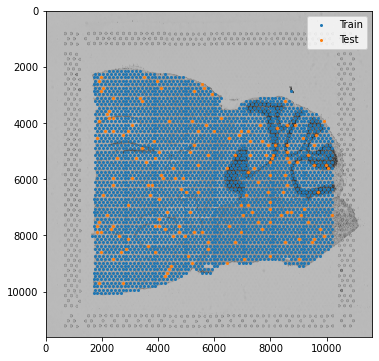

In [10]:
# Plot training & testing distribution
plt.figure(figsize=(6, 6))
plt.imshow(image_norm[..., 0], cmap="gray")
coords_x = pd_meta.loc[training_indexes, "Y"].values
coords_y = pd_meta.loc[training_indexes, "X"].values
plt.scatter(coords_x, coords_y, s=4, label="Train")
coords_x = pd_meta.loc[testing_indexes, "Y"].values
coords_y = pd_meta.loc[testing_indexes, "X"].values
plt.scatter(coords_x, coords_y, s=4, label="Test")
plt.gca().set_aspect('equal')
plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0)
plt.legend()
plt.show()

In [11]:
# Log2
count = np.log2(count + 1)

# Normalize gene_stat by divided with max
count_max = np.log2(count_stat.loc['max', :].values + 1)
count_max[count_max < 1] = 1
count = count/count_max

In [12]:
count

,0610005C13Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610010F05Rik,0610010K14Rik,0610012G03Rik,0610025J13Rik,0610030E20Rik,0610033M10Rik,...,mt-Co2,mt-Co3,mt-Cytb,mt-Nd1,mt-Nd2,mt-Nd3,mt-Nd4,mt-Nd4l,mt-Nd5,mt-Nd6
0,0.0,0.680827,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.837193,0.0,...,0.889707,0.885431,0.885664,0.875950,0.865035,0.853302,0.796349,0.510652,0.719033,0.000000
1,0.0,0.000000,0.0,0.423208,0.000000,0.545078,0.655566,0.0,0.000000,0.0,...,0.880957,0.865422,0.872079,0.875045,0.871658,0.870267,0.784839,0.520219,0.714286,0.000000
2,0.0,0.572497,0.0,0.488207,0.000000,0.525044,0.674907,0.0,0.000000,0.0,...,0.884663,0.879155,0.907810,0.890759,0.892870,0.858009,0.840273,0.653568,0.775277,0.635964
3,0.0,0.626644,0.0,0.000000,0.587219,0.574703,0.629785,0.0,0.000000,0.0,...,0.894821,0.909021,0.923737,0.934028,0.915472,0.885322,0.845102,0.619603,0.745615,0.000000
4,0.0,0.742110,0.0,0.000000,0.000000,0.589270,0.645749,0.0,0.000000,0.0,...,0.895621,0.888814,0.886252,0.897902,0.900999,0.824025,0.819301,0.600470,0.703195,0.713758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3350,0.0,0.000000,0.0,0.000000,0.000000,0.562176,0.000000,0.0,0.000000,0.0,...,0.889373,0.896588,0.895472,0.878298,0.898752,0.858368,0.821459,0.609251,0.748754,0.000000
3351,0.0,0.674109,0.0,0.490377,0.538863,0.671697,0.677488,0.0,0.707111,0.0,...,0.672794,0.731306,0.708679,0.727599,0.691517,0.610039,0.652853,0.000000,0.494094,0.638790
3352,0.0,0.603551,0.0,0.000000,0.000000,0.463453,0.664871,0.0,0.000000,0.0,...,0.867870,0.869717,0.875017,0.853068,0.860455,0.820570,0.789442,0.551265,0.700271,0.561361
3353,0.0,0.000000,0.0,0.500441,0.000000,0.000000,0.748081,0.0,0.000000,0.0,...,0.900381,0.905201,0.899347,0.903534,0.888600,0.885645,0.826730,0.613563,0.761378,0.000000


In [13]:
PATCH_SIZE = 256

## 2) Check data loader

In [14]:
# from utils_data import Dataset
from utils_data import normalize, augmentor

import numpy as np
import math
import skimage
import skimage.transform

import torch
import torch.utils
import torch.utils.data
    
# Get image patch
def get_image_patch(image, coords, patch_size):
    """
    Args:
        coords: center of image; x, y (col, row) in pixels
    """
    row_start = int(coords[1] - patch_size/2)
    col_start = int(coords[0] - patch_size/2)
    return image[row_start:row_start + patch_size, col_start:col_start + patch_size]

class Dataset(torch.utils.data.Dataset):
    __initialized = False
    def __init__(self, indexes, image, count_df, meta_df, augmentation=False):
        """
        Args:
            indexes: index used for both count_df and meta_df
        """
        self.indexes = indexes
        self.image = image
        self.count_df = count_df
        self.meta_df = meta_df
        self.augmentation = augmentation
        self.__initialized = True

    def __len__(self):
        """Denotes the number of samples"""
        return len(self.indexes)
    
    def __getitem__(self, index):
        """Generate one batch of data.
        
        Returns:
            index: indexes of samples (long)
        """
        # Generate data
        data = self.__data_generation(self.indexes[index])

        return data, index
    
    def __data_generation(self, indexes):
        """Generates data containing batch_size samples.
        
        Returns:
            data: a dictionary with data.image in [b, ch, h, w]; data.gene in [b, n_genes]
        """
        image = get_image_patch(self.image, 
                                [self.meta_df.loc[indexes, "Y"], self.meta_df.loc[indexes, "X"]], 
                                PATCH_SIZE)  # meta_df mistakes X/Y
        if self.augmentation:
            image = augmentor(normalize(image))
        else:
            image = normalize(image)
        
        data = dict()
        data['image'] = torch.tensor(np.transpose(image, (2, 0, 1)).astype(float))
        data['gene'] = torch.tensor(self.count_df.loc[indexes, :].values)
        
        return data 

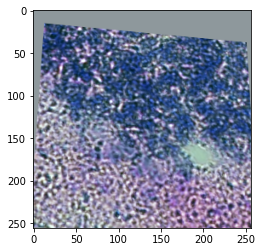

tensor([1648])


In [15]:
# Generator
np.random.seed()
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=True, num_workers=1)
for x, y in train_loader:
    plt.imshow(normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True))
    plt.show()
    print(y)
    break

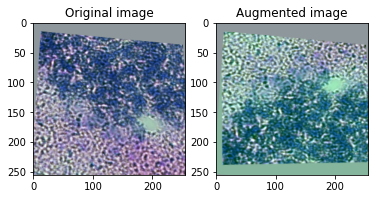

In [16]:
image = normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True)
plt.subplot(121)
plt.imshow(image)
plt.title("Original image")
plt.subplot(122)
plt.imshow(normalize(augmentor(normalize(image)), inverse=True))
plt.title("Augmented image")
plt.show()

## 3) Create network

In [19]:
from torch.nn.modules import MSELoss
device = torch.device("cuda:0")
image_shape = PATCH_SIZE
n_genes = count_stat.shape[1]
n_data = len(training_indexes)
n_out_features = 100
imagenet = 'resnet101'

# NCE parameters
nce_k = 100
nce_t = 0.07
nce_m = 0.9
softmax = False

# Training parameters
lr = 0.01   
momentum = 0.9
weight_decay = 0.0001
gradient_clip = 5

# Generator
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=20, shuffle=True, num_workers=1)
test_set = Dataset(testing_indexes, image_norm, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

# Set model
model = MicNet(image_shape=image_shape, n_genes=n_genes, n_out_features=n_out_features, 
               imagenet=imagenet, genenet=[500, 100]).to(device)
contrast = NCEAverage(n_out_features, n_data, nce_k, nce_t, nce_m, softmax, device=device).to(device)
criterion_image = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)
criterion_gene = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)
criterion_rec = MSELoss().to(device)

# Set optimizer
optimizer = torch.optim.SGD(model.parameters(),
                            lr=lr,
                            momentum=momentum,
                            weight_decay=weight_decay)

In [20]:
model_dir = "./models/Dataset_MPB"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

In [21]:
model

MicNet(
  (imagenet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          

In [22]:
"""TO LOAD:"""
model_file = os.path.join(model_dir, 'epoch_best.pt')
if model_file is not None:
    print("=> loading checkpoint '{}'".format(model_file))
    checkpoint = torch.load(model_file, map_location=device)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    contrast.load_state_dict(checkpoint['contrast'])
    del checkpoint

=> loading checkpoint './models/Dataset_MPB/epoch_best.pt'


## 4) Validate and save result

In [23]:
test_set = Dataset(indexes_all, image_norm, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

In [24]:
model.eval()

with torch.no_grad():
    for idx, (data, index) in enumerate(test_loader):
        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        feat_image, feat_gene = model(data)
        
        # Append
        if idx == 0:
            feat_images = feat_image.cpu().numpy()
            feat_genes = feat_gene.cpu().numpy()
        else:
            feat_images = np.concatenate([feat_images, feat_image.cpu().numpy()])
            feat_genes = np.concatenate([feat_genes, feat_gene.cpu().numpy()])

In [25]:
feat_images.shape

(3355, 100)

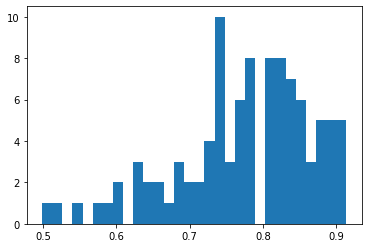

In [26]:
# Normalize & calculate correlation
from scipy.stats import spearmanr

feat_images = feat_images / np.sum(feat_images ** 2, axis=1, keepdims=True) ** 0.5
feat_genes = feat_genes / np.sum(feat_genes ** 2, axis=1, keepdims=True) ** 0.5
corr = []
for i in range(feat_images.shape[1]):
    corr.append(spearmanr(feat_images[:, i], feat_genes[:, i]).correlation)
plt.hist(corr, bins=30)
plt.show()

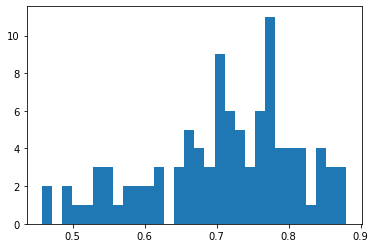

In [27]:
# Normalize & calculate correlation in testing set
from scipy.stats import spearmanr

_feat_images = np.array([feat_images[_, :] for _, index in enumerate(indexes_all) if index in testing_indexes])
_feat_genes = np.array([feat_genes[_, :] for _, index in enumerate(indexes_all) if index in testing_indexes])
corr = []
for i in range(_feat_images.shape[1]):
    corr.append(spearmanr(_feat_images[:, i], _feat_genes[:, i]).correlation)
plt.hist(corr, bins=30)
plt.show()

In [29]:
torch.save([feat_images, feat_genes],"./output/Dataset_MPB/3_MicNet_mouse_brain_posterior.pt")

# 5) Clustering

In [36]:
### Read annotation
GT= pd.read_csv("./Sample_data/Dataset_MPB/Ground_Truth.csv",index_col=0)
GT

,X,Y,class_gt_2
16,2617,4737,layer 2/3
22,4294,5701,layer 1
25,2617,5013,layer 2/3
37,3336,3085,layer 6
45,4773,4324,layer 4/5
...,...,...,...
3324,2617,5563,layer 1
3325,3455,5219,layer 4/5
3329,4174,3980,subiculum
3341,4054,5426,layer 2/3


In [39]:
feat_images, feat_genes = torch.load("./output/Dataset_MPB/3_MicNet_mouse_brain_posterior.pt")

image_feature = feat_images
gene_feature = feat_genes

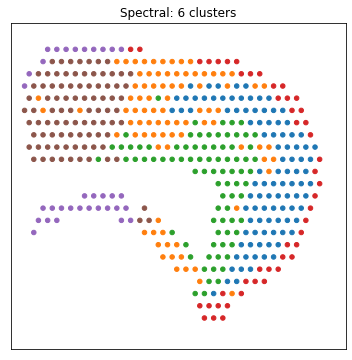

In [52]:
coords_x = pd_meta.loc[:, "Y"].values
coords_y = pd_meta.loc[:, "X"].values
xmin = 1500
xmax = 6500
ymin = 2000
ymax = 5200
from sklearn.cluster import SpectralClustering, KMeans, MiniBatchKMeans

_select = [idx for idx in GT_raw.index if idx in indexes_all]

cluster_df = pd.DataFrame(index=pd_meta.index.values[_select])
for n_clusters in [6]:

    method = SpectralClustering(n_clusters=n_clusters, n_neighbors=10, random_state=0, assign_labels='discretize')
    name = "Spectral"
    
    # Combined feature
    X = np.concatenate((image_feature, gene_feature), axis=1)
    X_filter = X[np.logical_not(np.any(np.isnan(X), 1)), :]
    X_filter = X_filter[_select, :]
    X = X_filter

    model = method.fit(X_filter)
    Y = np.zeros([X.shape[0]])
    Y[:] = np.nan
    Y[np.logical_not(np.any(np.isnan(X), 1))] = model.labels_
    Y_image = Y.copy()

    # Match cluster from Y to Y_image
    Y_gene = Y.copy()
    Y = np.zeros_like(Y)
    Y[:] = np.nan
    matched_clusters = set()
    # Sort clusters from matched ratio high to low
    to_matched_clusters = np.argsort([np.max([np.sum(Y_image[Y_gene == to_matched_cluster] == _)/\
                                              np.sum(Y_gene == to_matched_cluster)
                                              for _ in range(n_clusters)])
                                      for to_matched_cluster in range(n_clusters)])[::-1]  

    for to_matched_cluster in to_matched_clusters:
        corresponding_image_clusters = np.argsort([np.sum(Y_image[Y_gene == to_matched_cluster] == _) for _ in range(n_clusters)])[::-1]
        for corresponding_image_cluster in corresponding_image_clusters:
            if corresponding_image_cluster not in matched_clusters:
                # print(to_matched_cluster, corresponding_image_cluster)
                Y[Y_gene == to_matched_cluster] = corresponding_image_cluster
                matched_clusters = matched_clusters | set([corresponding_image_cluster])
                break
                
    # Set color
    if n_clusters <= 10:
        cmap = plt.get_cmap("tab10")
    else:
        cmap = plt.get_cmap("tab20")
    _mycolor = [cmap(int(_)) for _ in Y]

    plt.figure(figsize=(6, 6))
    # plt.subplot(122)
    #plt.imshow(image_norm)
    fig = plt.scatter(coords_x[_select], coords_y[_select], c=_mycolor, s=20)
    plt.title('{}: {} clusters'.format(name, n_clusters))
    # plt.axis('off')
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)
    plt.xlim(xmin, xmax)
    plt.ylim(ymax, ymin)
    plt.show()
    
    cluster_df.loc[:, "combinedfeature_{}_clusters".format(n_clusters)] = [int(_) for _ in Y]

In [53]:
cluster_df

,combinedfeature_6_clusters
16,1
22,3
25,0
37,5
45,3
...,...
3324,3
3325,0
3329,1
3341,0


In [54]:
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.preprocessing import LabelEncoder

# Ground truth
gt = GT['class_gt_2']

# Dictionary of prediction dataframes
pred_dfs = {
    "MicNet": cluster_df,
}

# Store results
scores = {}

for name, df in pred_dfs.items():
    # pick the right label column
    if "combinedfeature_6_clusters" in df.columns:
        Y = df['combinedfeature_6_clusters'].to_numpy()
    elif "cluster" in df.columns:
        Y = df['cluster'].to_numpy()

    # Masks: keep only samples with both predictions and GT
    mask_pred = pd.notna(Y)
    mask_gt   = gt.notna().to_numpy()
    mask_common = mask_pred & mask_gt

    y_true = gt.to_numpy()[mask_common]
    y_pred = Y[mask_common]

    # Encode both true and predicted labels as integers
    le_true = LabelEncoder()
    y_true_enc = le_true.fit_transform(y_true)

    le_pred = LabelEncoder()
    y_pred_enc = le_pred.fit_transform(y_pred)

    # Compute ARI and AMI
    ari = adjusted_rand_score(y_true_enc, y_pred_enc)
    ami = adjusted_mutual_info_score(y_true_enc, y_pred_enc)

    scores[name] = {"ARI": ari, "AMI": ami, "n_samples": mask_common.sum()}

# Print results
for name, score in scores.items():
    print(f"{name}: ARI={score['ARI']:.4f}, AMI={score['AMI']:.4f} (n={score['n_samples']})")


MicNet: ARI=0.2843, AMI=0.3927 (n=434)


ARI: 0.2842766008749859


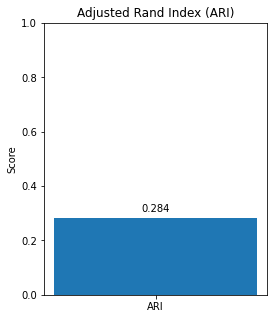

In [55]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
print("ARI:", ari)

# ---- Plot ----
plt.figure(figsize=(4, 5))
plt.bar(['ARI'], [ari])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Adjusted Rand Index (ARI)")
for i, v in enumerate([ari]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')

plt.show()

# Session Info

In [33]:
!pip freeze

absl-py==0.7.0
adjustText==0.7.3
altair==3.2.0
anndata==0.7.5
argh==0.26.2
ase==3.21.1
astor==0.7.1
astropy==3.2.1
atomicwrites==1.3.0
attrs==19.1.0
autograd==1.3
autograd-gamma==0.5.0
backcall==0.1.0
base58==1.0.3
bleach==1.5.0
blinker==1.4
boto3==1.10.15
botocore==1.13.15
Bottleneck==1.2.1
cachetools==4.1.0
certifi==2021.5.30
chardet==3.0.4
charset-normalizer==2.0.4
Click==7.0
cvxopt==1.2.3
cvxpy==1.0.24
cycler==0.10.0
Cython==0.29.15
dataclasses==0.8
decorator==4.4.0
defusedxml==0.5.0
dill==0.2.9
docutils==0.15.2
ecos==2.0.7.post1
entrypoints==0.3
enum-compat==0.0.3
environment-kernels==1.1.1
fastcluster==1.2.4
FITS-tools==0.2
formulaic==0.2.4
future==0.17.1
gast==0.2.2
get-version==2.1
google-auth==1.14.3
google-auth-oauthlib==0.4.1
google-pasta==0.2.0
googledrivedownloader==0.4
grpcio==1.29.0
h5py==2.10.0
html5lib==0.9999999
idna==3.2
image-registration==0.2.4
imagecodecs==2020.5.30
imagecodecs-lite==2020.1.31
imageio==2.6.1
importlib-metadata==0.23
interface-meta==1.2.3
ipykernel